In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
import os

In [14]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [15]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,    
    api_key=os.getenv("GROQ_API_KEY"),
)

def chat_node(state: ChatState):
    messages = state['messages']

    response = llm.invoke(messages)

    return {'messages':[response]}

In [16]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)

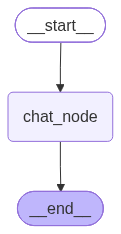

In [17]:
chatbot

In [18]:
initial_state = {
    'messages':[HumanMessage(content='What is AI?')]
    }

chatbot.invoke(initial_state)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [19]:
thread_id = '1'
while True:
    user_message = input('Type Here: ')

    print('User Message: ', user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    config = {'configurable': {'thread_id':thread_id}}

    response = chatbot.invoke({'messages':[HumanMessage(content=user_message)]}, config=config)

    print('AI: ', response['messages'][-1].content)

User Message:  Hello
AI:  Hello! How can I assist you today?
User Message:  im butterfly
AI:  That’s a beautiful way to describe yourself! 🦋

What’s fluttering through your mind today? Feel free to share any thoughts, questions, or stories—whether you’re soaring over a garden of ideas or just enjoying a gentle breeze. I'm here to chat!
User Message:  who am i
AI:  It sounds like you’re curious about your own identity—something many of us wonder about at different points in life. While I don’t have any personal details about you, I can help you explore the question in a few ways:

### 1. **Reflect on Your Roles**
Think about the different “hats” you wear day‑to‑day:
- **Relationships:** friend, sibling, partner, parent, colleague, mentor…
- **Activities:** student, creator, athlete, gamer, volunteer, hobbyist…
- **Values:** what matters most to you? Kindness, curiosity, independence, community…

### 2. **Identify Core Traits**
Ask yourself:
- What three adjectives would you use to descr